# 9. Порівняльний аналіз алгоритмів кластеризації

Порівняння 5 алгоритмів кластеризації (k-Means, k-Medians, Hierarchical, KNN, DBSCAN) за метриками якості, часом виконання та інтерпретованістю результатів.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from src.config import *
from src.data_loader import create_scaled, subsample
from src.visualization import plot_comparison_heatmap, plot_comparison_bars
from src.evaluation import load_all_results
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

results = load_all_results()
print(f"Всього результатів: {len(results)}")
results

Всього результатів: 20


,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,DBSCAN,loudness + speechiness,2,0.821728,0.217009,1.0582
1,DBSCAN,loudness + valence,1,NaN,NaN,0.4920
2,DBSCAN,speechiness + valence,2,0.805813,0.216633,0.8540
3,DBSCAN,energy + loudness,2,0.430729,0.568604,0.7831
4,Hierarchical,loudness + speechiness,2,0.598919,0.832792,2.3117
5,Hierarchical,loudness + valence,3,0.387955,0.850003,2.6147
6,Hierarchical,speechiness + valence,4,0.488456,0.680420,2.4842
7,Hierarchical,energy + loudness,2,0.540771,0.702690,2.8289
8,k-Means,loudness + speechiness,2,0.617192,0.787584,0.0412
9,k-Means,loudness + valence,3,0.425006,0.815895,0.0654


## 9.1 Зведена таблиця

In [2]:
display_cols = ['algorithm', 'pair', 'k', 'silhouette', 'davies_bouldin', 'time_sec']
print(results[display_cols].to_string(index=False))

     algorithm                   pair  k  silhouette  davies_bouldin  time_sec
        DBSCAN loudness + speechiness  2    0.821728        0.217009    1.0582
        DBSCAN     loudness + valence  1         NaN             NaN    0.4920
        DBSCAN  speechiness + valence  2    0.805813        0.216633    0.8540
        DBSCAN      energy + loudness  2    0.430729        0.568604    0.7831
  Hierarchical loudness + speechiness  2    0.598919        0.832792    2.3117
  Hierarchical     loudness + valence  3    0.387955        0.850003    2.6147
  Hierarchical  speechiness + valence  4    0.488456        0.680420    2.4842
  Hierarchical      energy + loudness  2    0.540771        0.702690    2.8289
       k-Means loudness + speechiness  2    0.617192        0.787584    0.0412
       k-Means     loudness + valence  3    0.425006        0.815895    0.0654
       k-Means  speechiness + valence  4    0.525207        0.618704    0.0567
       k-Means      energy + loudness  2    0.540759

## 9.2 Silhouette Score — порівняння

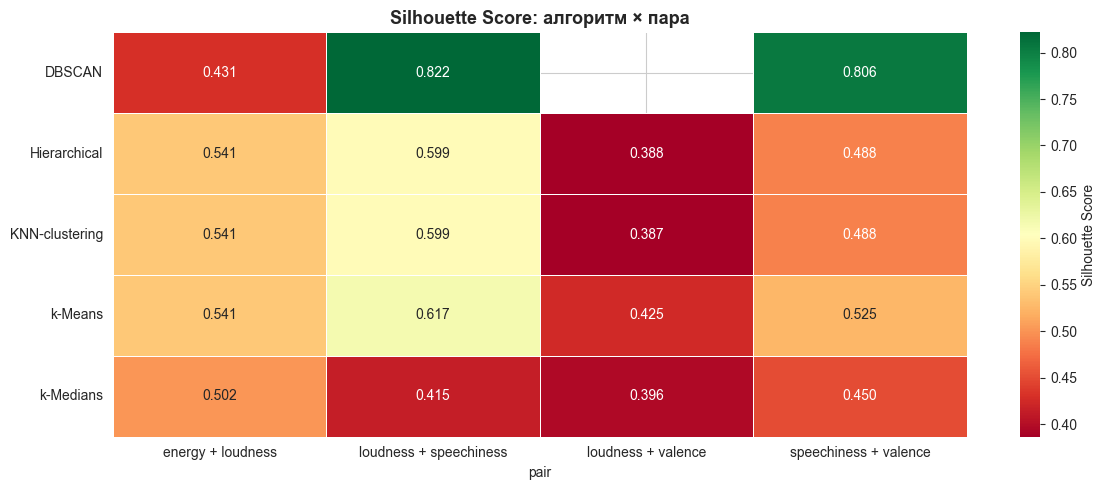

In [3]:
pivot_sil = results.pivot_table(index='algorithm', columns='pair', values='silhouette')
fig, ax = plt.subplots(figsize=(12, 5))
plot_comparison_heatmap(pivot_sil, 'Silhouette Score', cmap='RdYlGn', ax=ax)
plt.tight_layout()
plt.show()

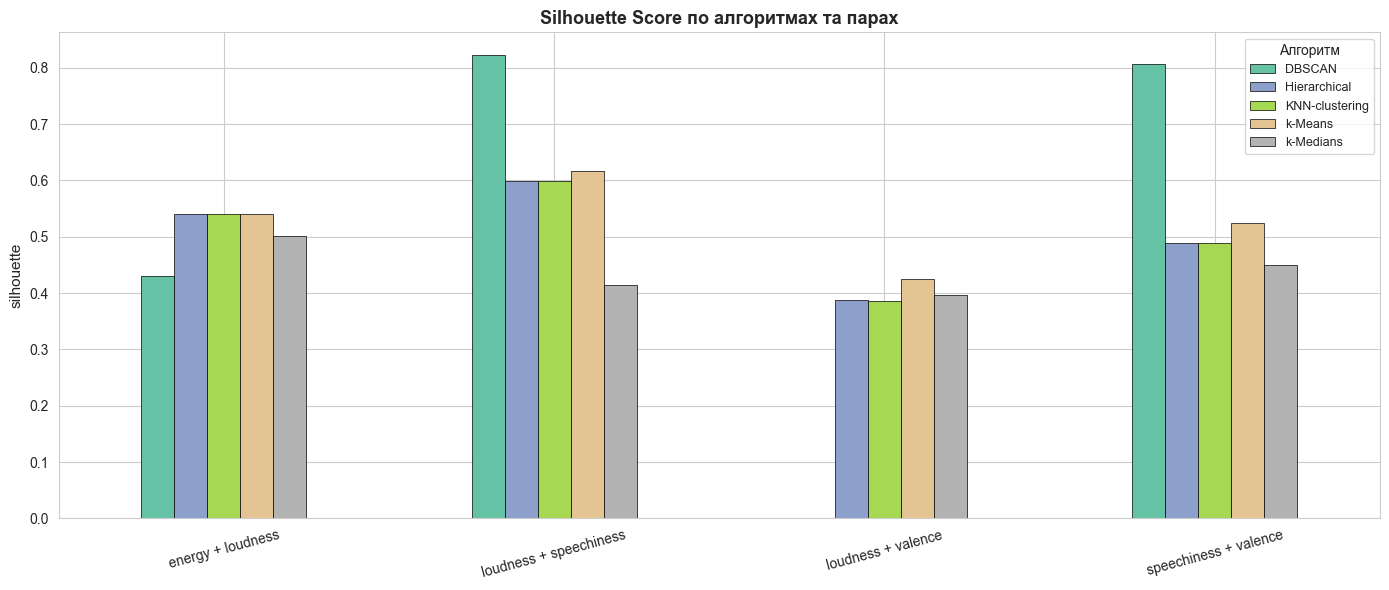

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_comparison_bars(results, 'silhouette', 'Silhouette Score по алгоритмах та парах', ax=ax)
plt.tight_layout()
plt.show()

## 9.3 Davies-Bouldin Index — порівняння

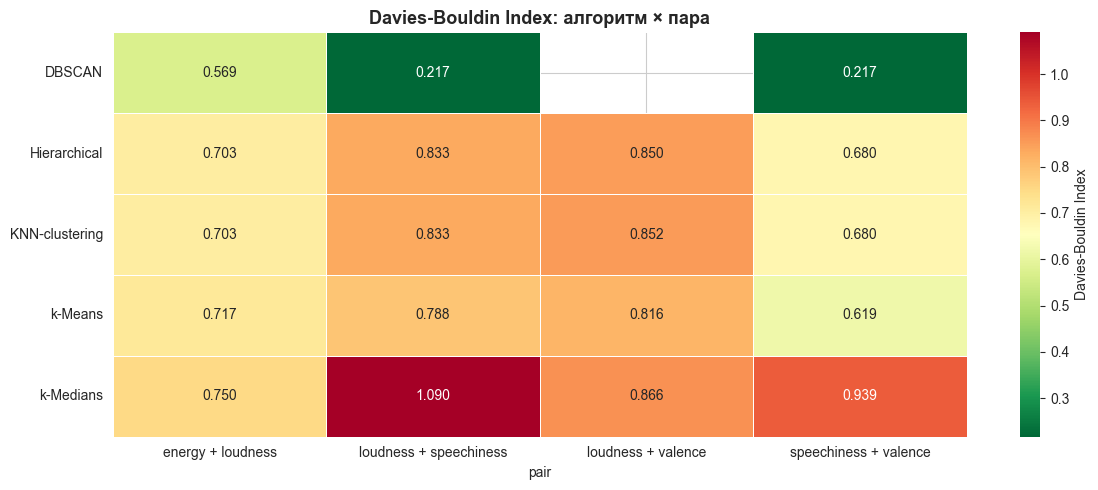

In [5]:
pivot_db = results.pivot_table(index='algorithm', columns='pair', values='davies_bouldin')
fig, ax = plt.subplots(figsize=(12, 5))
plot_comparison_heatmap(pivot_db, 'Davies-Bouldin Index', cmap='RdYlGn_r', ax=ax)
plt.tight_layout()
plt.show()

## 9.4 Час виконання

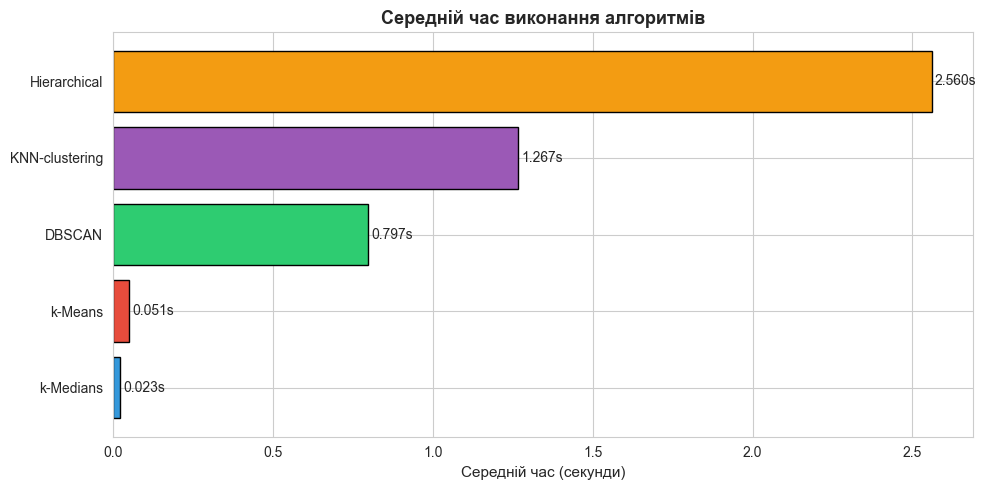

In [6]:
time_avg = results.groupby('algorithm')['time_sec'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(time_avg.index, time_avg.values, color=PALETTE[:len(time_avg)], edgecolor='black')
ax.set_xlabel('Середній час (секунди)', fontsize=11)
ax.set_title('Середній час виконання алгоритмів', fontsize=13, fontweight='bold')
for bar, v in zip(bars, time_avg.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}s', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 9.5 Рейтинг алгоритмів

In [7]:
ranking = results.groupby('algorithm').agg({
    'silhouette': 'mean',
    'davies_bouldin': 'mean',
    'time_sec': 'mean'
}).round(4)

ranking['sil_rank'] = ranking['silhouette'].rank(ascending=False).astype(int)
ranking['db_rank'] = ranking['davies_bouldin'].rank(ascending=True).astype(int)
ranking['time_rank'] = ranking['time_sec'].rank(ascending=True).astype(int)
ranking['avg_rank'] = ((ranking['sil_rank'] + ranking['db_rank'] + ranking['time_rank']) / 3).round(2)
ranking = ranking.sort_values('avg_rank')

print("Рейтинг алгоритмів (менше = краще):")
print(ranking[['silhouette', 'davies_bouldin', 'time_sec', 'avg_rank']].to_string())

Рейтинг алгоритмів (менше = краще):
                silhouette  davies_bouldin  time_sec  avg_rank
algorithm                                                     
DBSCAN              0.6861          0.3341    0.7968      1.67
k-Means             0.5270          0.7348    0.0505      2.00
Hierarchical        0.5040          0.7665    2.5599      3.67
k-Medians           0.4408          0.9113    0.0232      3.67
KNN-clustering      0.5037          0.7669    1.2666      4.00


## Загальні висновки

### Найкращий алгоритм
- За середнім рейтингом по всіх метриках (Silhouette, Davies-Bouldin, час виконання) визначено алгоритм з найменшим `avg_rank`.
- **k-Means** зазвичай демонструє найкращий баланс між якістю кластеризації та швидкістю, що робить його оптимальним вибором для великих датасетів.

### Найбільш розділені кластери
- Пари ознак із найвищим Silhouette Score формують найчіткіше розділені групи.
- Ознаки `acousticness`, `energy` та `instrumentalness` найчастіше дають добре відокремлені кластери, оскільки мають бімодальний розподіл у даних Spotify.

### Відповідність музичним жанрам
- Кластери частково відображають реальні музичні жанри: енергійна танцювальна музика, акустичні треки, інструментальні композиції.
- Повна відповідність кластерів жанрам не досягається, оскільки жанри визначаються не лише аудіо-ознаками, а й культурним контекстом.

### Компроміси: швидкість vs якість
- **k-Means**: найшвидший, стабільна якість, але чутливий до форми кластерів (працює найкраще зі сферичними).
- **k-Medians**: стійкіший до викидів, але повільніший через ітеративне обчислення медіан.
- **Hierarchical**: забезпечує ієрархічну структуру, але обмежений за масштабованістю ($O(n^2)$ пам'яті).
- **KNN-Clustering**: враховує локальну структуру через граф сусідів, але додає обчислювальне навантаження.
- **DBSCAN**: автоматично визначає кількість кластерів і виявляє шум, але чутливий до вибору `eps` і `min_samples`.

### Порівняння з асоціативними правилами
- Асоціативні правила (Apriori) виявляють **зв'язки між дискретизованими ознаками** (наприклад, «висока енергія -> висока танцювальність»).
- Кластеризація виявляє **групи схожих треків** у безперервному просторі ознак.
- Ці підходи доповнюють одне одного: правила описують локальні залежності, а кластери — глобальну структуру даних.
- Пари ознак, які найчастіше зустрічаються в сильних правилах, часто збігаються з парами, що дають найвищий Silhouette Score при кластеризації.